# UCI Wine: Classical LDA/QDA with Missing Values

This notebook uses a well-known dataset (UCI Wine) and introduces missing values before fitting the same classical methods used in the main examples: `LDAClassifier` and `QDAClassifier`. Outputs focus on metrics and plots rather than array shapes.

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix

from missing_methods import get_class_colors
from missing_methods.lda import lda, plot_lda_regions
from missing_methods.qda import qda, plot_qda_regions, plot_qda_boundary_segments
from missing_methods.sk import LDAClassifier, QDAClassifier, PCA

In [17]:
def inject_mcar(X, rate=0.18, seed=0):
    """Randomly set a fraction of entries to NaN (MCAR)."""
    rng = np.random.default_rng(seed)
    X_nan = np.asarray(X, dtype=float).copy()
    mask = rng.random(X_nan.shape) < float(rate)
    X_nan[mask] = np.nan
    return X_nan, mask

def summarize_model(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
    }

In [18]:
wine = load_wine()
X = wine.data.astype(float)
y = wine.target.astype(int)
class_names = wine.target_names
feature_names = wine.feature_names

# Stratified split keeps class proportions stable across train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

missing_rate = 0.18
X_train_miss, train_missing_mask = inject_mcar(X_train, rate=missing_rate, seed=7)
X_test_miss, test_missing_mask = inject_mcar(X_test, rate=missing_rate, seed=9)

lda_clf = LDAClassifier(impute_ncomp=0.9, regularization=1e-5)
qda_clf = QDAClassifier(impute_ncomp=0.9, regularization=1e-5)

lda_clf.fit(X_train_miss, y_train)
qda_clf.fit(X_train_miss, y_train)

y_pred_lda = lda_clf.predict(X_test_miss)
y_pred_qda = qda_clf.predict(X_test_miss)

metrics_lda = summarize_model(y_test, y_pred_lda)
metrics_qda = summarize_model(y_test, y_pred_qda)

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features, {np.unique(y).size} classes")
print(f"Train missing fraction: {train_missing_mask.mean():.3f}")
print(f"Test missing fraction:  {test_missing_mask.mean():.3f}")

Dataset: 178 samples, 13 features, 3 classes
Train missing fraction: 0.179
Test missing fraction:  0.174


Metrics on test set:
LDAClassifier  | acc=0.870 | bal_acc=0.877 | macro_f1=0.871
QDAClassifier  | acc=0.870 | bal_acc=0.865 | macro_f1=0.872


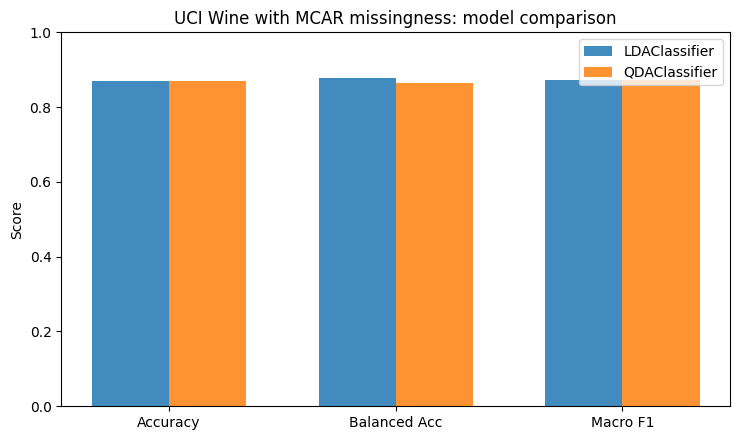

In [19]:
model_names = ["LDAClassifier", "QDAClassifier"]
metric_names = ["accuracy", "balanced_accuracy", "macro_f1"]
metric_values = np.array([
    [metrics_lda[m] for m in metric_names],
    [metrics_qda[m] for m in metric_names],
], dtype=float)

print("Metrics on test set:")
for i, name in enumerate(model_names):
    vals = metric_values[i]
    print(f"{name:14s} | acc={vals[0]:.3f} | bal_acc={vals[1]:.3f} | macro_f1={vals[2]:.3f}")

# Side-by-side bars make relative metric differences easy to compare.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = np.arange(len(metric_names))
width = 0.34
ax.bar(x - width / 2, metric_values[0], width=width, label=model_names[0], alpha=0.85)
ax.bar(x + width / 2, metric_values[1], width=width, label=model_names[1], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(["Accuracy", "Balanced Acc", "Macro F1"])
ax.set_ylim(0.0, 1.0)
ax.set_ylabel("Score")
ax.set_title("UCI Wine with MCAR missingness: model comparison")
ax.legend()
plt.tight_layout()
plt.show()

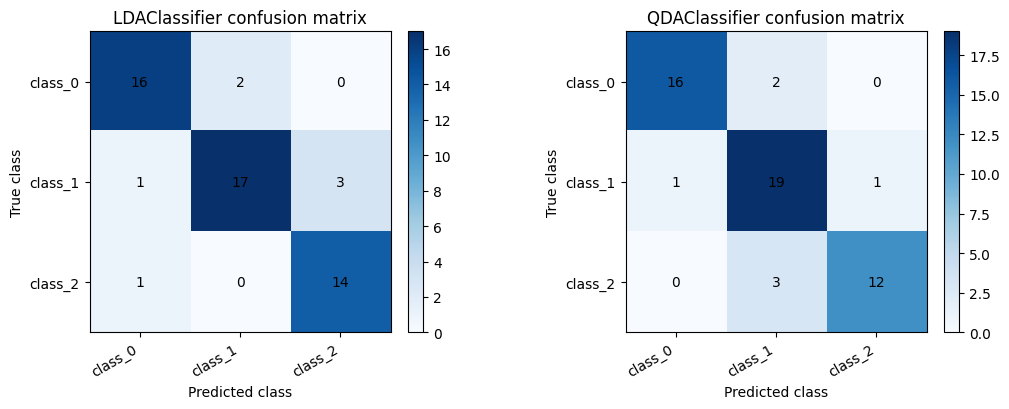

In [20]:
cm_lda = confusion_matrix(y_test, y_pred_lda, labels=np.arange(len(class_names)))
cm_qda = confusion_matrix(y_test, y_pred_qda, labels=np.arange(len(class_names)))

# Confusion matrices show which class pairs are hardest for each classifier.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, cm, title in [
    (axes[0], cm_lda, "LDAClassifier confusion matrix"),
    (axes[1], cm_qda, "QDAClassifier confusion matrix"),
]:
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=30, ha="right")
    ax.set_yticklabels(class_names)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

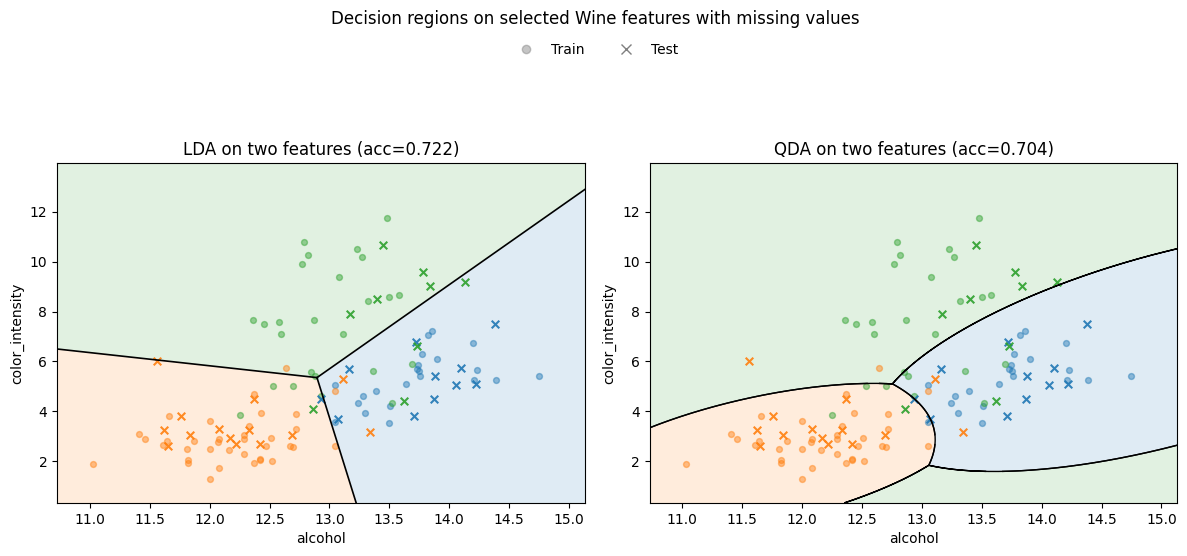

In [21]:
# 2-D visualization view: use two original Wine features for interpretable boundaries.
viz_idx = [0, 9]  # alcohol, color_intensity
T_train = X_train_miss[:, viz_idx]
T_test = X_test_miss[:, viz_idx]
viz_feature_names = [feature_names[viz_idx[0]], feature_names[viz_idx[1]]]

lda_2d = lda(T_train, y_train, X_new=T_test, impute_ncomp=0.9)
qda_2d = qda(T_train, y_train, X_new=T_test, impute_ncomp=0.9)

acc_lda_2d = accuracy_score(y_test, lda_2d["new_fitted"])
acc_qda_2d = accuracy_score(y_test, qda_2d["new_fitted"])
class_colors = get_class_colors(len(class_names))

# Compute shared padded limits so LDA and QDA panels are directly comparable.
all_2d = np.vstack([T_train, T_test])
x0 = float(np.nanmin(all_2d[:, 0]))
x1 = float(np.nanmax(all_2d[:, 0]))
y0 = float(np.nanmin(all_2d[:, 1]))
y1 = float(np.nanmax(all_2d[:, 1]))
dx = max(1e-9, x1 - x0)
dy = max(1e-9, y1 - y0)
xlim = (x0 - 0.08 * dx, x1 + 0.08 * dx)
ylim = (y0 - 0.08 * dy, y1 + 0.08 * dy)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
plot_lda_regions(
    lda_2d,
    ax=axes[0],
    xlim=xlim,
    ylim=ylim,
    alpha=0.14,
    draw_segments=True,
    line_kwargs={"color": "black", "linewidth": 1.2},
    class_colors=class_colors,
    train_X=T_train,
    train_y=y_train,
    test_X=T_test,
    test_y=y_test,
)
axes[0].set_title(f"LDA on two features (acc={acc_lda_2d:.3f})")
axes[0].set_xlabel(viz_feature_names[0])
axes[0].set_ylabel(viz_feature_names[1])

plot_qda_regions(
    qda_2d,
    ax=axes[1],
    xlim=xlim,
    ylim=ylim,
    alpha=0.14,
    draw_pairwise=False,
    class_colors=class_colors,
    train_X=T_train,
    train_y=y_train,
    test_X=T_test,
    test_y=y_test,
)
plot_qda_boundary_segments(
    qda_2d,
    ax=axes[1],
    xlim=axes[1].get_xlim(),
    ylim=axes[1].get_ylim(),
    n_samples=900,
    line_kwargs={"color": "black", "linewidth": 1.0},
)
axes[1].set_title(f"QDA on two features (acc={acc_qda_2d:.3f})")
axes[1].set_xlabel(viz_feature_names[0])
axes[1].set_ylabel(viz_feature_names[1])

legend_handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", markersize=6, markerfacecolor="gray", alpha=0.45, color="gray", label="Train"),
    plt.Line2D([0], [0], marker="x", linestyle="", markersize=7, color="gray", label="Test"),
]
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False)
fig.suptitle("Decision regions on selected Wine features with missing values", y=1.06)
plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()